# Load data

In [511]:
with open("top_english_words_lower_50000.txt", 'r') as words_file:
    words = words_file.read().splitlines()
words = list(filter(lambda w: len(w) > 3, words))
len(words)

46839

In [512]:
min(len(w) for w in words)

4

In [513]:
max(len(w) for w in words)

20

### Preprocess words into those only containing english alphabet letters

In [514]:
from itertools import pairwise

ALPHABET = "abcdefghijklmnopqrstuvwxyz"

def bigramize(word):
    dot_word = f".{word}."
    for fst, snd in pairwise(dot_word):
        yield fst, snd

def bigram_gen(words):
    for word in words:
        yield from bigramize(word)

def is_latin(word):
    return all(c in ALPHABET for c in word)

def norm(word):
    return word.lower()

In [515]:
from typing import Counter

norm_words = map(norm, words)
alpha_words = list(filter(is_latin, norm_words))
bigrams = bigram_gen(alpha_words)

### Count bigrams

In [516]:
counter = Counter(bigrams)

In [517]:
stoi = {s: i for i, s in enumerate(ALPHABET, start=1)}
stoi["."] = 0
itos = {v: k for k, v in stoi.items()}

In [518]:
import torch

N = torch.zeros(size=(27, 27), dtype=torch.int16)
for (fst, scd), ct in counter.items():
    i, j = stoi[fst], stoi[scd]
    N[i, j] = ct

smoothing = 1
N += smoothing

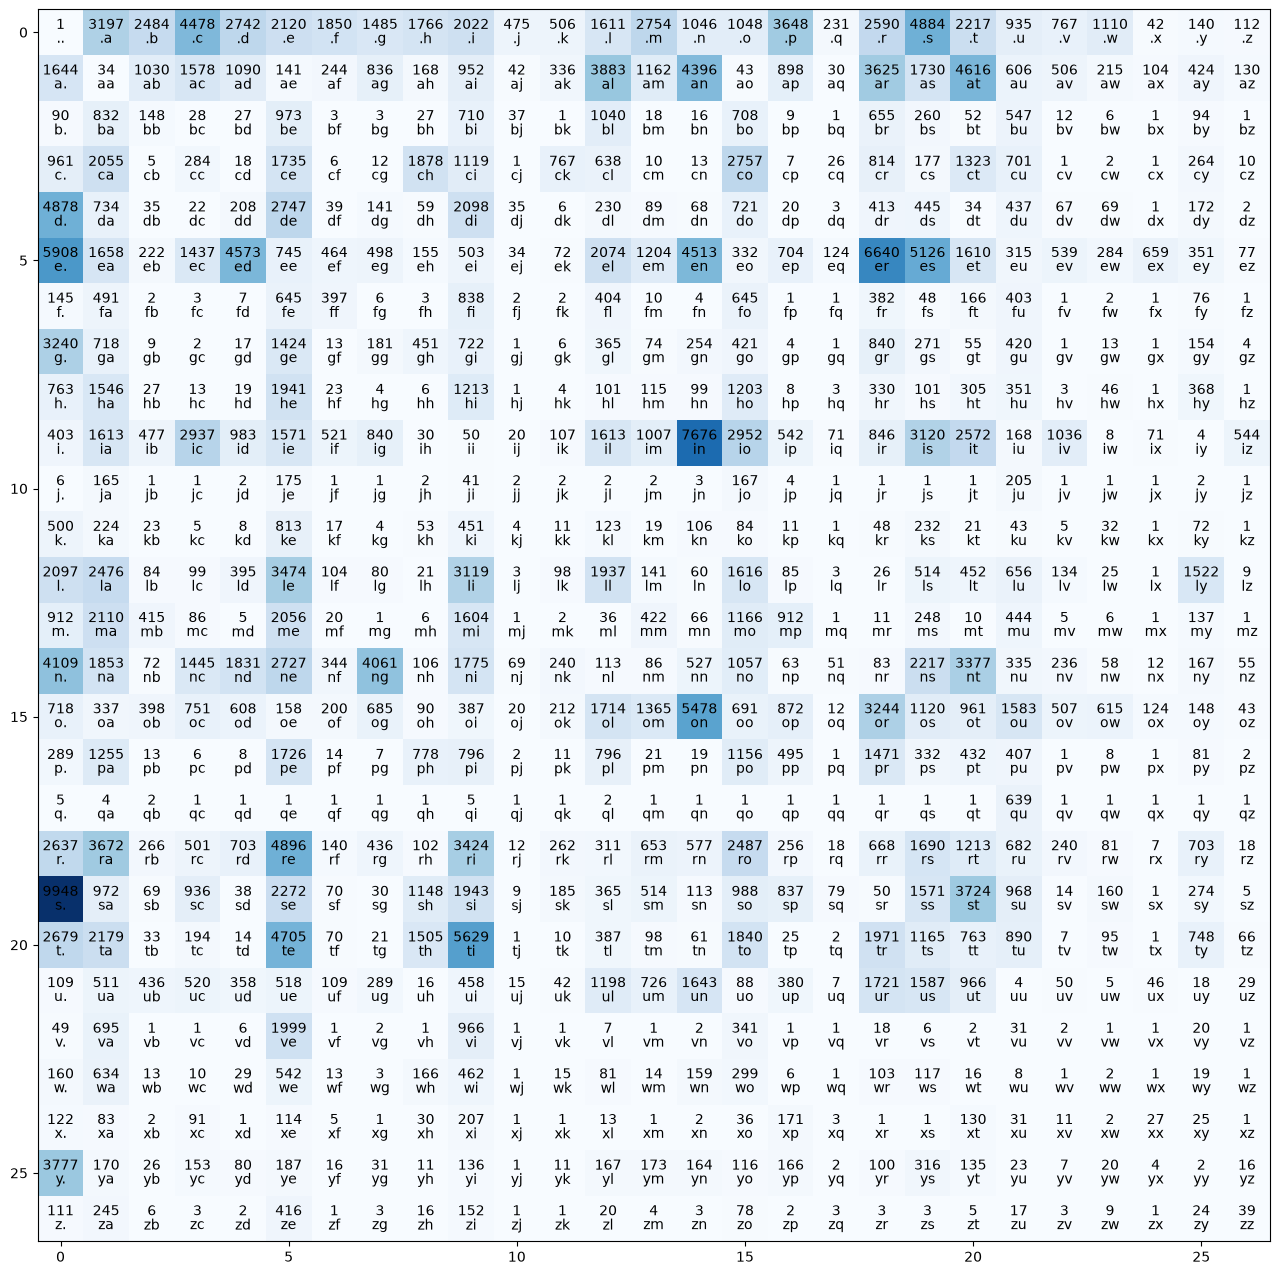

In [519]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 16))
plt.imshow(N, cmap="Blues")
for i in range(27):
    for j in range(27):
        chs = itos[i] + itos[j]
        plt.text(j, i, chs, ha="center", va="top")
        plt.text(j, i, str(N[i, j].item()), ha="center", va="bottom")

### Turn counts into probabilities

In [520]:
row_sums = N.sum(dim=1, keepdim=True, dtype=torch.float)
N = N.div(row_sums)

# Generate using probabilities of next letter

In [521]:
GEN = torch.Generator().manual_seed(42)
MAX_WORD_LEN = 20

def next_letter(current_letter):
    idx = stoi[current_letter]
    probs = N[idx, :]
    next_idx = torch.multinomial(probs, num_samples=1, replacement=True, generator=GEN).item()
    return itos[next_idx] # type: ignore

for _ in range(5):
    current_letter = "."
    constructed = ""
    for _ in range(MAX_WORD_LEN):
        current_letter = next_letter(current_letter)
        if current_letter == ".":
            break
        constructed += current_letter
    print(constructed)

ctugedove
s
fabidushontubun
silay
g


# Proto Neural Net

### Define input and targets

In [522]:
import torch.nn.functional as F

dot_words = "." + ".".join(alpha_words) + "."
int_words = torch.tensor([stoi[w] for w in dot_words])
one_hots = F.one_hot(int_words, num_classes=27).float()
xs = one_hots[:-1]
ys = one_hots[1:]

### Initialize 'net'

In [523]:
GEN = torch.Generator().manual_seed(42)
W = torch.randn(size=(27, 27), requires_grad=True, generator=GEN)

### Learning the net

In [526]:
EPOCH = 500
LEARNING_RATE = 50

for e in range(EPOCH):
    preds = F.softmax(xs @ W, dim=1)
    loss = -torch.log((preds * ys).sum(dim=1)).mean()
    print(f"{e:<3}: Loss = {loss.item()}")
    loss.backward()

    with torch.no_grad():
        assert W.grad is not None
        W.sub_(LEARNING_RATE * W.grad) # type: ingore
    W.grad.zero_()

0  : Loss = 2.5166711807250977
1  : Loss = 2.51662278175354
2  : Loss = 2.5165748596191406
3  : Loss = 2.5165281295776367
4  : Loss = 2.5164809226989746
5  : Loss = 2.516435146331787
6  : Loss = 2.5163888931274414
7  : Loss = 2.5163440704345703
8  : Loss = 2.516299247741699
9  : Loss = 2.5162551403045654
10 : Loss = 2.51621150970459
11 : Loss = 2.5161678791046143
12 : Loss = 2.516125440597534
13 : Loss = 2.5160834789276123
14 : Loss = 2.5160417556762695
15 : Loss = 2.5160000324249268
16 : Loss = 2.5159592628479004
17 : Loss = 2.515918731689453
18 : Loss = 2.515878915786743
19 : Loss = 2.515839099884033
20 : Loss = 2.5158002376556396
21 : Loss = 2.515761137008667
22 : Loss = 2.5157229900360107
23 : Loss = 2.5156848430633545
24 : Loss = 2.5156476497650146
25 : Loss = 2.5156102180480957
26 : Loss = 2.515573740005493
27 : Loss = 2.5155375003814697
28 : Loss = 2.5155012607574463
29 : Loss = 2.51546573638916
30 : Loss = 2.515430450439453
31 : Loss = 2.5153956413269043
32 : Loss = 2.515360832

### Generating words based on probabilities learner by net

In [532]:
GEN = torch.Generator().manual_seed(42)
MAX_WORD_LEN = 20

def next_letter_nn(current_letter):
    idx = torch.tensor(stoi[current_letter])
    x = F.one_hot(idx, num_classes=27).float()
    y = (x @ W).exp()
    probs = y / y.sum()
    next_idx = torch.multinomial(probs, num_samples=1, replacement=True, generator=GEN).item()
    return itos[next_idx] # type: ignore

for _ in range(5):
    current_letter = "."
    constructed = ""
    for _ in range(MAX_WORD_LEN):
        current_letter = next_letter_nn(current_letter)
        if current_letter == ".":
            break
        constructed += current_letter
    print(constructed)

ctugedove
s
fabidushontubun
silay
g
